# 10 Baseline R1: Taxonomy-Relevance Sensitivity

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
cwd = Path.cwd()
PROJECT_ROOT = cwd.parent if cwd.name == 'notebooks' else cwd
PROCESSED_DIR = PROJECT_ROOT / 'data' / 'processed'
NOTEBOOK_OUTPUT_DIR = PROJECT_ROOT / 'outputs' / '10_baseline_r1_taxonomy_relevance'
FIGURE_DIR = NOTEBOOK_OUTPUT_DIR / 'figures'
TABLE_DIR = NOTEBOOK_OUTPUT_DIR / 'tables'
DATA_OUTPUT_DIR = NOTEBOOK_OUTPUT_DIR / 'data'
FIGURE_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)
DATA_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
GENDER_CATEGORIES = ['MM', 'MW', 'WM', 'WW']
pd.set_option('display.max_columns', 120)
pd.set_option('display.float_format', lambda x: f'{x:,.4f}')

In [2]:
def standardize_edges(edges):
    out = edges[['citing_paper_id', 'cited_paper_id']].copy()
    out['citing_paper_id'] = out['citing_paper_id'].astype(str)
    out['cited_paper_id'] = out['cited_paper_id'].astype(str)
    return out

def load_final_core():
    papers = pd.read_pickle(PROCESSED_DIR / 'papers_final.pkl')
    cs_papers = pd.read_pickle(PROCESSED_DIR / 'cs_papers_final.pkl')
    all_edges = standardize_edges(pd.read_pickle(PROCESSED_DIR / 'citation_edges_final.pkl'))
    all_to_cs = standardize_edges(pd.read_pickle(PROCESSED_DIR / 'citation_edges_all_to_cs_final.pkl'))
    cs_to_cs = standardize_edges(pd.read_pickle(PROCESSED_DIR / 'citation_edges_cs_to_cs_final.pkl'))
    papers['id'] = papers['id'].astype(str)
    cs_papers['id'] = cs_papers['id'].astype(str)
    return (papers, cs_papers, all_edges, all_to_cs, cs_to_cs)

def known_cs(cs_papers):
    return cs_papers[cs_papers['first_last_cat'].isin(GENDER_CATEGORIES)].copy()

def aggregate_oe(observed, expected, baseline, citation_slice):
    rows = []
    for g in GENDER_CATEGORIES:
        o = float(observed.get(g, 0.0))
        e = float(expected.get(g, 0.0))
        oe = o / e if e > 0 else np.nan
        rows.append({'gender_cat': g, 'observed_citations': o, 'expected_citations': e, 'oe_ratio': oe, 'pct_diff_from_expected': (oe - 1.0) * 100 if pd.notna(oe) else np.nan, 'baseline': baseline, 'citation_slice': citation_slice})
    return pd.DataFrame(rows)

def prepare_cited_edges(edges, cs_known, extra_cols):
    meta_cols = ['id', 'first_last_cat'] + list(extra_cols)
    meta = cs_known[meta_cols].drop_duplicates('id').rename(columns={'id': 'cited_paper_id', 'first_last_cat': 'cited_gender'})
    return edges.merge(meta, on='cited_paper_id', how='inner')

## 1. Load and enrich final edges

In [3]:
papers, cs_papers, citation_edges_final, edges_all_to_cs, edges_cs_to_cs = load_final_core()
cs_known = known_cs(cs_papers)
META = ['id', 'decade', 'primary_topic_id', 'primary_topic_name', 'primary_subfield', 'primary_field', 'primary_domain', 'first_last_cat']
all_meta = papers[[c for c in META if c in papers.columns]].drop_duplicates('id').copy()
all_meta['id'] = all_meta['id'].astype(str)
cs_meta = cs_known[[c for c in META if c in cs_known.columns]].drop_duplicates('id').copy()

def enrich(edges):
    x = edges.copy()
    citing = all_meta.rename(columns={c: f'citing_{c}' for c in all_meta.columns if c != 'id'}).rename(columns={'id': 'citing_paper_id'})
    cited = cs_meta.rename(columns={c: f'cited_{c}' for c in cs_meta.columns if c != 'id'}).rename(columns={'id': 'cited_paper_id'})
    x = x.merge(citing, on='citing_paper_id', how='left')
    x = x.merge(cited, on='cited_paper_id', how='inner')
    return x
all_e = enrich(edges_all_to_cs)
cs_e = enrich(edges_cs_to_cs)
print(all_e.shape, cs_e.shape)

(8686237, 16) (7023500, 16)


## 2. D2 share lookup and relevance labels

In [4]:
d2_counts = cs_known.groupby(['decade', 'primary_subfield', 'first_last_cat'], dropna=False).size().rename('n').reset_index()
d2_counts['total'] = d2_counts.groupby(['decade', 'primary_subfield'], dropna=False)['n'].transform('sum')
d2_counts['share'] = d2_counts['n'] / d2_counts['total']
d2_wide = d2_counts.pivot_table(index=['decade', 'primary_subfield'], columns='first_last_cat', values='share', fill_value=0, dropna=False).reindex(columns=GENDER_CATEGORIES, fill_value=0).reset_index()

def add_relevance(x):
    x = x.copy()
    valid_topic = x['citing_primary_topic_id'].notna() & x['cited_primary_topic_id'].notna()
    valid_subfield = x['citing_primary_subfield'].notna() & x['cited_primary_subfield'].notna()
    valid_field = x['citing_primary_field'].notna() & x['cited_primary_field'].notna()
    valid_domain = x['citing_primary_domain'].notna() & x['cited_primary_domain'].notna()
    same_topic = valid_topic & x['citing_primary_topic_id'].eq(x['cited_primary_topic_id'])
    same_subfield = valid_subfield & x['citing_primary_subfield'].eq(x['cited_primary_subfield'])
    same_field = valid_field & x['citing_primary_field'].eq(x['cited_primary_field'])
    same_domain = valid_domain & x['citing_primary_domain'].eq(x['cited_primary_domain'])
    x['same_topic'] = same_topic
    x['same_subfield'] = same_subfield
    x['cross_topic_same_subfield'] = same_subfield & ~same_topic
    x['cross_subfield'] = valid_subfield & ~same_subfield
    x['relevance_level'] = np.select([same_topic, same_subfield & ~same_topic, same_field & ~same_subfield, same_domain & ~same_field], ['same_topic', 'same_subfield_only', 'same_field_only', 'same_domain_only'], default='outside_shared_hierarchy')
    x['relevance_weight'] = np.select([same_topic, same_subfield & ~same_topic, same_field & ~same_subfield, same_domain & ~same_field], [1.0, 0.75, 0.5, 0.25], default=0.0)
    x = x.merge(d2_wide, left_on=['cited_decade', 'cited_primary_subfield'], right_on=['decade', 'primary_subfield'], how='left')
    return x
all_e = add_relevance(all_e)
cs_e = add_relevance(cs_e)

## 3. Compute hard and weighted R1 variants

In [5]:
def r1_for_edges(x, citation_slice):
    pieces = []
    subsets = {'same_topic': x['same_topic'], 'same_subfield': x['same_subfield'], 'cross_topic_same_subfield': x['cross_topic_same_subfield'], 'cross_subfield': x['cross_subfield']}
    for name, mask in subsets.items():
        z = x.loc[mask].copy()
        obs = z['cited_first_last_cat'].value_counts().reindex(GENDER_CATEGORIES, fill_value=0)
        exp = z[GENDER_CATEGORIES].sum().reindex(GENDER_CATEGORIES, fill_value=0)
        out = aggregate_oe(obs, exp, f'R1_{name}', citation_slice)
        out['n_edges'] = len(z)
        pieces.append(out)
    z = x[x['relevance_weight'] > 0].copy()
    obs = z.groupby('cited_first_last_cat')['relevance_weight'].sum().reindex(GENDER_CATEGORIES, fill_value=0)
    exp = pd.Series({g: (z['relevance_weight'] * z[g]).sum() for g in GENDER_CATEGORIES})
    out = aggregate_oe(obs, exp, 'R1_taxonomy_weighted', citation_slice)
    out['n_edges'] = len(z)
    out['total_relevance_weight'] = z['relevance_weight'].sum()
    pieces.append(out)
    return pd.concat(pieces, ignore_index=True)
r1_all = r1_for_edges(all_e, 'All→CS')
r1_cs = r1_for_edges(cs_e, 'CS→CS')
r1_results = pd.concat([r1_all, r1_cs], ignore_index=True)
r1_results

,gender_cat,observed_citations,expected_citations,oe_ratio,pct_diff_from_expected,baseline,citation_slice,n_edges,total_relevance_weight
0,MM,"2,837,184.0000","2,764,419.8159",1.0263,2.6322,R1_same_topic,All→CS,3630264,NaN
1,MW,"293,324.0000","295,104.9565",0.9940,-0.6035,R1_same_topic,All→CS,3630264,NaN
2,WM,"375,192.0000","401,562.2213",0.9343,-6.5669,R1_same_topic,All→CS,3630264,NaN
3,WW,"124,564.0000","169,177.0063",0.7363,-26.3706,R1_same_topic,All→CS,3630264,NaN
4,MM,"3,968,615.0000","3,844,019.5107",1.0324,3.2413,R1_same_subfield,All→CS,5027849,NaN
5,MW,"392,051.0000","403,969.3648",0.9705,-2.9503,R1_same_subfield,All→CS,5027849,NaN
6,WM,"498,919.0000","548,427.0549",0.9097,-9.0273,R1_same_subfield,All→CS,5027849,NaN
7,WW,"168,264.0000","231,433.0696",0.7271,-27.2947,R1_same_subfield,All→CS,5027849,NaN
8,MM,"1,131,431.0000","1,079,599.6948",1.0480,4.8010,R1_cross_topic_same_subfield,All→CS,1397585,NaN
9,MW,"98,727.0000","108,864.4083",0.9069,-9.3120,R1_cross_topic_same_subfield,All→CS,1397585,NaN


## 4. Relevance distributions

In [6]:
relevance_distribution_all_to_cs = all_e['relevance_level'].value_counts(dropna=False).rename_axis('relevance_level').reset_index(name='n_edges')
relevance_distribution_cs_to_cs = cs_e['relevance_level'].value_counts(dropna=False).rename_axis('relevance_level').reset_index(name='n_edges')
relevance_distribution_all_to_cs

,relevance_level,n_edges
0,same_topic,3630264
1,same_field_only,1995651
2,same_subfield_only,1397585
3,same_domain_only,1031157
4,outside_shared_hierarchy,631580


## 5. Visualize

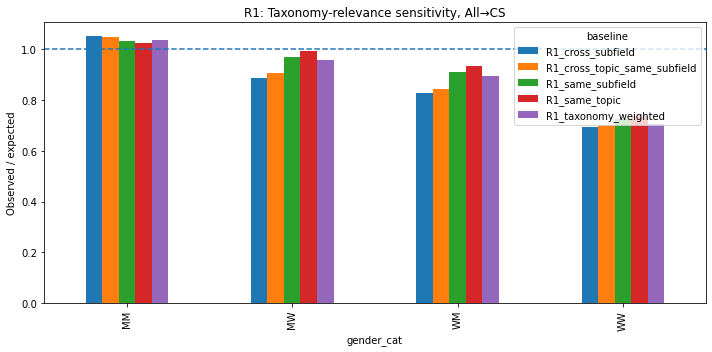

In [7]:
plot = r1_all.pivot(index='gender_cat', columns='baseline', values='oe_ratio').reindex(GENDER_CATEGORIES)
ax = plot.plot(kind='bar', figsize=(10, 5))
ax.axhline(1.0, linestyle='--')
ax.set_ylabel('Observed / expected')
ax.set_title('R1: Taxonomy-relevance sensitivity, All→CS')
plt.tight_layout()
plt.savefig(FIGURE_DIR / 'baseline_r1_taxonomy_relevance_all_to_cs.png', dpi=300)
plt.show()

## 6. Save outputs

In [8]:
r1_results.to_csv(TABLE_DIR / 'r1_taxonomy_relevance_oe_by_gender.csv', index=False)
r1_all.to_csv(TABLE_DIR / 'baseline_r1_taxonomy_relevance_all_to_cs_summary.csv', index=False)
r1_cs.to_csv(TABLE_DIR / 'baseline_r1_taxonomy_relevance_cs_to_cs_summary.csv', index=False)
relevance_distribution_all_to_cs.to_csv(TABLE_DIR / 'baseline_r1_relevance_distribution_all_to_cs.csv', index=False)
relevance_distribution_cs_to_cs.to_csv(TABLE_DIR / 'baseline_r1_relevance_distribution_cs_to_cs.csv', index=False)
print('Saved:', NOTEBOOK_OUTPUT_DIR)

Saved: c:\Users\blaze\OneDrive\Documents\GitHub\citation-gender-imbalance\outputs\10_baseline_r1_taxonomy_relevance
